# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [24]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

In [6]:
for column in df.columns:
    print(f"{column}: {df[column].unique()}\n---------------------------")

num_passengers: [2 1 3 4 6 5 7 9 8]
---------------------------
sales_channel: <StringArray>
['Internet', 'Mobile']
Length: 2, dtype: str
---------------------------
trip_type: <StringArray>
['RoundTrip', 'CircleTrip', 'OneWay']
Length: 3, dtype: str
---------------------------
purchase_lead: [262 112 243  96  68   3 201 238  80 378 185   8 265 245 192 259  19  67
 351 228  21  23  25  16  66  51  37 101   7   5  33  20  56  13  71 346
   9  65 221 107  14  77  24  47  22  11  35 272 250 161 128 190 311  27
 314 102   2  26  32  57 198 120  69 281 282  15  31 316 232 156 196 283
  34  63   6 227 181 138 134  85  93 118  90 168 127  18 153 186 263 172
 230  42  81 140 285 179 341 173 180 366 229 174  82  75 163 105 276 110
  83 154  55  45  54 193  10 166  97 239 182  99  53  28 384  70 126 142
  87  86 313  41  91 206 197 268 157 145 241 139  59 396 280  79 380 132
 121 419  58 115 236 225 116 191 275 417 159  92 106 218 295  12 305 235
 332 125 204 310 368 169 214 155 325 130 189 226 

In [18]:
filteredMobileChannels= df[(df['sales_channel']=='Internet')]
m=filteredMobileChannels["booking_complete"].value_counts()
print(m)
print(f"completing {(m[1]/(m.sum()))*100}")
print(f"not completing {(m[0]/(m.sum()))*100}")

booking_complete
0    37513
1     6869
Name: count, dtype: int64
completing 15.476995178225405
not completing 84.52300482177459


In [19]:
filteredMobileChannels= df[(df['sales_channel']=='Mobile')]
m=filteredMobileChannels["booking_complete"].value_counts()
print(m)
print(f"completing {(m[1]/(m.sum()))*100}")
print(f"not completing {(m[0]/(m.sum()))*100}")

booking_complete
0    5009
1     609
Name: count, dtype: int64
completing 10.840156639373442
not completing 89.15984336062655


In [20]:
df.shape

(50000, 14)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


In [26]:
print(df.describe())

       num_passengers  purchase_lead  length_of_stay  flight_hour  \
count    50000.000000   50000.000000     50000.00000  50000.00000   
mean         1.591240      84.940480        23.04456      9.06634   
std          1.020165      90.451378        33.88767      5.41266   
min          1.000000       0.000000         0.00000      0.00000   
25%          1.000000      21.000000         5.00000      5.00000   
50%          1.000000      51.000000        17.00000      9.00000   
75%          2.000000     115.000000        28.00000     13.00000   
max          9.000000     867.000000       778.00000     23.00000   

       wants_extra_baggage  wants_preferred_seat  wants_in_flight_meals  \
count         50000.000000          50000.000000           50000.000000   
mean              0.668780              0.296960               0.427140   
std               0.470657              0.456923               0.494668   
min               0.000000              0.000000               0.000000   
25%

In [27]:
df["booking_complete"].value_counts()

booking_complete
0    42522
1     7478
Name: count, dtype: int64

In [32]:
df.columns

Index(['num_passengers', 'sales_channel', 'trip_type', 'purchase_lead',
       'length_of_stay', 'flight_hour', 'flight_day', 'route',
       'booking_origin', 'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals', 'flight_duration', 'booking_complete'],
      dtype='str')

In [39]:
for column in df.columns:
    print(f"\n----------{column}--------------")
    print(f"{df[column].value_counts().head(10)}")


----------num_passengers--------------
num_passengers
1    31352
2    12804
3     2941
4     1784
5      561
6      289
7      114
8       89
9       66
Name: count, dtype: int64

----------sales_channel--------------
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

----------trip_type--------------
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

----------purchase_lead--------------
purchase_lead
1     685
2     670
6     653
7     638
5     615
13    606
4     606
8     597
9     593
20    589
Name: count, dtype: int64

----------length_of_stay--------------
length_of_stay
6     7757
5     7286
4     5655
3     2839
17    1849
21    1392
18    1356
20    1285
22    1285
19    1253
Name: count, dtype: int64

----------flight_hour--------------
flight_hour
8     3165
12    3163
9     3132
7     3126
11    3110
13    3101
10    3085
6     3050
5     2851
4     2843
Name: count, dtype: int64

----------flight_d

In [38]:
print(df.describe(include="all"))

        num_passengers sales_channel  trip_type  purchase_lead  \
count     50000.000000         50000      50000   50000.000000   
unique             NaN             2          3            NaN   
top                NaN      Internet  RoundTrip            NaN   
freq               NaN         44382      49497            NaN   
mean          1.591240           NaN        NaN      84.940480   
std           1.020165           NaN        NaN      90.451378   
min           1.000000           NaN        NaN       0.000000   
25%           1.000000           NaN        NaN      21.000000   
50%           1.000000           NaN        NaN      51.000000   
75%           2.000000           NaN        NaN     115.000000   
max           9.000000           NaN        NaN     867.000000   

        length_of_stay  flight_hour flight_day   route booking_origin  \
count      50000.00000  50000.00000      50000   50000          50000   
unique             NaN          NaN          7     799       

In [40]:
df.groupby("sales_channel")['booking_complete'].mean()

sales_channel
Internet    0.154770
Mobile      0.108402
Name: booking_complete, dtype: float64

In [41]:
df.groupby("trip_type")['booking_complete'].mean()

trip_type
CircleTrip    0.043103
OneWay        0.051680
RoundTrip     0.150575
Name: booking_complete, dtype: float64

In [48]:
df.groupby("flight_day")['booking_complete'].mean().sort_values(ascending=False).head(10)

flight_day
Wed    0.163148
Thu    0.151131
Mon    0.148605
Sat    0.148142
Tue    0.147139
Fri    0.145393
Sun    0.141440
Name: booking_complete, dtype: float64

In [49]:
df.groupby("booking_origin")['booking_complete'].mean().sort_values(ascending=False).head(10)

booking_origin
Seychelles    1.000000
Iraq          1.000000
Pakistan      1.000000
Vanuatu       1.000000
Kazakhstan    0.666667
Bahrain       0.600000
Romania       0.500000
Denmark       0.428571
Sweden        0.416667
Malaysia      0.344020
Name: booking_complete, dtype: float64

In [53]:
m=df.groupby("trip_type")['booking_complete'].agg([
    "mean", "sum","count"
])
print(m)

                mean   sum  count
trip_type                        
CircleTrip  0.043103     5    116
OneWay      0.051680    20    387
RoundTrip   0.150575  7453  49497


In [71]:
m=df.groupby("booking_complete")[
    [
         "num_passengers",
        "purchase_lead",
        "length_of_stay",
        "flight_hour",
        "flight_duration",
    ]
].mean()
print(m)

                  num_passengers  purchase_lead  length_of_stay  flight_hour  \
booking_complete                                                               
0                       1.580923      85.779926       23.647218     9.050162   
1                       1.649906      80.167157       19.617679     9.158331   

                  flight_duration  
booking_complete                   
0                        7.344266  
1                        6.898258  


In [70]:
prefs=[
    'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals'
]
m=df.groupby(prefs)['booking_complete'].mean()
print(m)

wants_extra_baggage  wants_preferred_seat  wants_in_flight_meals
0                    0                     0                        0.106743
                                           1                        0.120725
                     1                     0                        0.130155
                                           1                        0.153575
1                    0                     0                        0.159329
                                           1                        0.150629
                     1                     0                        0.183319
                                           1                        0.185975
Name: booking_complete, dtype: float64


In [63]:
for pf in prefs:
    print(f"\n-----------{pf}----------")
    m=df.groupby(pf)["booking_complete"].agg(["mean", "count"])
    print(m)


-----------wants_extra_baggage----------
                         mean  count
wants_extra_baggage                 
0                    0.115029  16561
1                    0.166662  33439

-----------wants_preferred_seat----------
                          mean  count
wants_preferred_seat                 
0                     0.137944  35152
1                     0.177061  14848

-----------wants_in_flight_meals----------
                           mean  count
wants_in_flight_meals                 
0                      0.141396  28643
1                      0.160509  21357


In [84]:
prefs=[
    'wants_extra_baggage', 'wants_preferred_seat',
       'wants_in_flight_meals'
]
df['extra_totals']=df[prefs[0]]+df[prefs[1]]+df[prefs[2]]
# m=df[0]+df[1]+df[2]
m=df.groupby('extra_totals')["booking_complete"].agg(["mean", "count", "sum"])
print(m)

                  mean  count   sum
extra_totals                       
0             0.106743  10455  1116
1             0.149594  18216  2725
2             0.159726  12559  2006
3             0.185975   8770  1631


In [87]:
m=pd.get_dummies(df,columns=['trip_type'])
print(m)

       num_passengers sales_channel  purchase_lead  length_of_stay  \
0                   2      Internet            262              19   
1                   1      Internet            112              20   
2                   2      Internet            243              22   
3                   1      Internet             96              31   
4                   2      Internet             68              22   
...               ...           ...            ...             ...   
49995               2      Internet             27               6   
49996               1      Internet            111               6   
49997               1      Internet             24               6   
49998               1      Internet             15               6   
49999               1      Internet             19               6   

       flight_hour flight_day   route booking_origin  wants_extra_baggage  \
0                7        Sat  AKLDEL    New Zealand                    1   
1    

In [95]:
x=df.drop("booking_complete", axis=1)

y=df['booking_complete']




route: 799
Booking origins: 104


In [97]:
print(f"route: {df['route'].nunique()}")
print("Booking origins:", df["booking_origin"].nunique())
print("Trip types:", df["trip_type"].nunique())
print("Flight days:", df["flight_day"].nunique())
print("Sales channels:", df["sales_channel"].nunique())

xx=pd.get_dummies(df,columns=['route'])
print(xx)

route: 799
Booking origins: 104
Trip types: 3
Flight days: 7
Sales channels: 2
       num_passengers sales_channel  trip_type  purchase_lead  length_of_stay  \
0                   2      Internet  RoundTrip            262              19   
1                   1      Internet  RoundTrip            112              20   
2                   2      Internet  RoundTrip            243              22   
3                   1      Internet  RoundTrip             96              31   
4                   2      Internet  RoundTrip             68              22   
...               ...           ...        ...            ...             ...   
49995               2      Internet  RoundTrip             27               6   
49996               1      Internet  RoundTrip            111               6   
49997               1      Internet  RoundTrip             24               6   
49998               1      Internet  RoundTrip             15               6   
49999               1      Int

In [122]:
# Removing the high cardility features as well as the target
x = df.drop(columns=["booking_origin",'route','booking_complete'])
y= df["booking_complete"]

# Encoding the categorical features:
x=pd.get_dummies(x,columns=['trip_type',"flight_day","sales_channel"], dtype=int)
x.head()
x.shape
x.dtypes

num_passengers             int64
sales_channel                str
trip_type                    str
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                   str
route                        str
booking_origin               str
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
extra_totals               int64
dtype: object

In [125]:
from sklearn.model_selection import train_test_split, cross_val_score

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2,random_state=42,stratify=y)
print(y_train.value_counts())
print(y_test.value_counts())

booking_complete
0    34018
1     5982
Name: count, dtype: int64
booking_complete
0    8504
1    1496
Name: count, dtype: int64


In [131]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

print(f"Accuracy:",accuracy_score(y_test,y_pred))
print(f"confusion matrix:",confusion_matrix(y_test,y_pred))
print(f"classification report:",classification_report(y_test,y_pred))

Accuracy: 0.8471
confusion matrix: [[8377  127]
 [1402   94]]
classification report:               precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.43      0.06      0.11      1496

    accuracy                           0.85     10000
   macro avg       0.64      0.52      0.51     10000
weighted avg       0.79      0.85      0.80     10000



In [133]:
balanced_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

balanced_model.fit(x_train, y_train)
y_pred_balanced = balanced_model.predict(x_test)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_balanced)
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(y_test, y_pred_balanced)
)

print("\nClassification Report:")
print(
    classification_report(y_test, y_pred_balanced)
)

Accuracy: 0.8036

Confusion Matrix:
[[7710  794]
 [1170  326]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      8504
           1       0.29      0.22      0.25      1496

    accuracy                           0.80     10000
   macro avg       0.58      0.56      0.57     10000
weighted avg       0.78      0.80      0.79     10000



In [136]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_results = cross_validate(
    balanced_model,
    x,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)
for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = cv_results[f"test_{metric}"]

    print(f"{metric}:")
    print("  folds:", scores)
    print("  mean:", scores.mean())
    print("  std:", scores.std())

accuracy:
  folds: [0.8051 0.8037 0.808  0.8068 0.8111]
  mean: 0.80694
  std: 0.002542911716910382
precision:
  folds: [0.28584906 0.29181495 0.30586081 0.29739777 0.31196172]
  mean: 0.2985768602177127
  std: 0.009394904122520783
recall:
  folds: [0.20267559 0.21939799 0.22326203 0.21390374 0.21791444]
  mean: 0.21543075849981222
  std: 0.007046455612719967
f1:
  folds: [0.237182   0.25047728 0.25811437 0.24883359 0.25659189]
  mean: 0.2502398274031494
  std: 0.007414823814967687
roc_auc:
  folds: [0.64916242 0.65634997 0.64443565 0.665814   0.65421529]
  mean: 0.6539954670025689
  std: 0.007211353347171362


In [148]:
feature_importance =pd.DataFrame({
    "feature":x.columns,
    "importance":balanced_model.feature_importances_,
})
feature_importance = feature_importance.sort_values("importance", ascending=False)

print(feature_importance.head(10))

            feature  importance
1     purchase_lead    0.262674
3       flight_hour    0.193803
2    length_of_stay    0.180497
7   flight_duration    0.138033
0    num_passengers    0.060602
8      extra_totals    0.020925
13   flight_day_Mon    0.014435
17   flight_day_Tue    0.014010
16   flight_day_Thu    0.013789
12   flight_day_Fri    0.013494


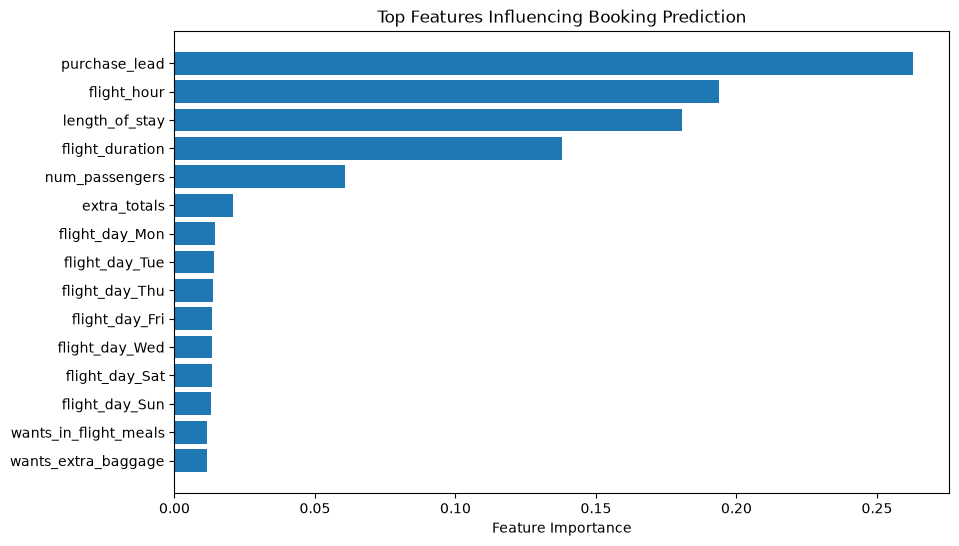

In [147]:
top_features=feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])

plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Features Influencing Booking Prediction")
plt.show()

In [149]:
X_origin = df.drop(
    columns=["booking_complete", "route"]
)

y = df["booking_complete"]

X_origin = pd.get_dummies(
    X_origin,
    columns=[
        "sales_channel",
        "trip_type",
        "flight_day",
        "booking_origin"
    ],
    dtype=int
)

print(X_origin.shape)

(50000, 125)


In [150]:
origin_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
origin_cv_results = cross_validate(
    origin_model,
    X_origin,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = origin_cv_results[f"test_{metric}"]

    print(f"{metric}:")
    print("  folds:", scores)
    print("  mean:", scores.mean())
    print("  std:", scores.std())

accuracy:
  folds: [0.8136 0.8155 0.8129 0.8136 0.8142]
  mean: 0.8139600000000001
  std: 0.0008731551981177382
precision:
  folds: [0.35990888 0.37075332 0.36481615 0.37204451 0.37181303]
  mean: 0.3678671789393927
  std: 0.004774785493435915
recall:
  folds: [0.31705686 0.33578595 0.33823529 0.35762032 0.35093583]
  mean: 0.3399268506429632
  std: 0.013980711939138976
f1:
  folds: [0.3371266  0.35240435 0.35102324 0.36468984 0.3610729 ]
  mean: 0.3532633875851126
  std: 0.009567701055731195
roc_auc:
  folds: [0.73679657 0.74709671 0.74278198 0.75263383 0.74705651]
  mean: 0.7452731210481438
  std: 0.005267705301483215


In [151]:
X_route = df.drop(
    columns=["booking_complete"]
)

y = df["booking_complete"]

X_route = pd.get_dummies(
    X_route,
    columns=[
        "sales_channel",
        "trip_type",
        "flight_day",
        "booking_origin",
        "route"
    ],
    dtype=int
)

print(X_route.shape)

(50000, 924)


In [152]:
route_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

route_cv_results = cross_validate(
    route_model,
    X_route,
    y,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    scores = route_cv_results[f"test_{metric}"]

    print(
        metric,
        "mean:", scores.mean(),
        "std:", scores.std()
    )

accuracy mean: 0.8227400000000001 std: 0.0015396103403134112
precision mean: 0.4009645924126525 std: 0.003934092080057336
recall mean: 0.37483036145440235 std: 0.011588773995334785
f1 mean: 0.3873652084845407 std: 0.006654260090236295
roc_auc mean: 0.7833534516053089 std: 0.0022093410327461917


In [153]:
route_model.fit(X_route, y)
final_importance = pd.DataFrame({
    "feature": X_route.columns,
    "importance": route_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print(final_importance.head(15))

                     feature  importance
1              purchase_lead    0.122459
2             length_of_stay    0.101618
3                flight_hour    0.100155
25  booking_origin_Australia    0.059139
7            flight_duration    0.041268
0             num_passengers    0.038839
72   booking_origin_Malaysia    0.032345
8               extra_totals    0.024088
15            flight_day_Mon    0.013548
19            flight_day_Tue    0.013000
18            flight_day_Thu    0.012800
20            flight_day_Wed    0.012541
17            flight_day_Sun    0.012256
14            flight_day_Fri    0.012201
6      wants_in_flight_meals    0.012155
